# Phase 8: Predictive Modeling

This notebook adds a focused predictive layer to the NYC 311 project by forecasting `resolution_bucket` from complaint intake features.

It focuses on:
- a time-based `2025` train and `2026` YTD test design
- baseline, linear, and tree-based benchmark comparison
- class-level confusion across resolution-time buckets
- interpretable feature signals and operational error slices

`2026` remains partial-year data, so this notebook frames the evaluation as YTD out-of-time testing rather than a full-year benchmark.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from predictive import build_predictive_outputs

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd()
TOP_FEATURES = 12
TOP_ERROR_SLICES = 10
FEATURE_SET_LABELS = {
    "post_routing": "Post-routing",
    "intake_only": "Intake-only",
    "shared": "Shared baseline",
}


def format_pct(value: float) -> str:
    if pd.isna(value):
        return "NA"
    return f"{value:.1%}"


def trim_table(df: pd.DataFrame, percent_cols=None) -> pd.DataFrame:
    display_df = df.copy()
    for column in percent_cols or []:
        if column in display_df.columns:
            display_df[column] = display_df[column].map(format_pct)
    return display_df


def lookup_metric(metrics: pd.DataFrame, feature_set: str, model_name: str, metric: str) -> float:
    return float(
        metrics.loc[
            metrics['feature_set'].eq(feature_set)
            & metrics['model_name'].eq(model_name)
            & metrics['metric'].eq(metric),
            'metric_value',
        ].iloc[0]
    )


In [2]:
(
    df,
    model_metrics,
    predictions,
    feature_importance,
    error_slices,
    confusion_matrix_df,
) = build_predictive_outputs()

overall_metrics = model_metrics.loc[model_metrics["metric_scope"].eq("overall")].copy()
class_metrics = model_metrics.loc[model_metrics["metric_scope"].eq("class")].copy()
benchmark_overall = overall_metrics.loc[overall_metrics['feature_set'].ne('shared')].copy()
best_by_feature_set = (
    benchmark_overall.loc[benchmark_overall['metric'].eq('macro_f1')]
    .sort_values(['feature_set', 'metric_value'], ascending=[True, False])
    .drop_duplicates(subset=['feature_set'])
    .reset_index(drop=True)
)
post_routing_best_model = best_by_feature_set.loc[best_by_feature_set['feature_set'].eq('post_routing'), 'model_name'].iloc[0]
intake_only_best_model = best_by_feature_set.loc[best_by_feature_set['feature_set'].eq('intake_only'), 'model_name'].iloc[0]
post_routing_best_confusion = confusion_matrix_df.loc[
    confusion_matrix_df['feature_set'].eq('post_routing')
    & confusion_matrix_df['model_name'].eq(post_routing_best_model)
].copy()
intake_only_best_confusion = confusion_matrix_df.loc[
    confusion_matrix_df['feature_set'].eq('intake_only')
    & confusion_matrix_df['model_name'].eq(intake_only_best_model)
].copy()
best_class_metrics = class_metrics.merge(
    best_by_feature_set.loc[:, ['feature_set', 'model_name']],
    on=['feature_set', 'model_name'],
    how='inner',
)
post_routing_logistic_predictions = predictions.loc[
    predictions['feature_set'].eq('post_routing') & predictions['model_name'].eq('multinomial_logistic')
].copy()

print(f"Rows in predictive frame: {len(df):,}")
print(f"Scored logistic prediction rows: {len(predictions):,}")
print(f"Distinct target classes: {df['resolution_bucket'].nunique():,}")
print(f"Best post-routing benchmark: {post_routing_best_model}")
print(f"Best intake-only benchmark: {intake_only_best_model}")
print("Phase 8 outputs refreshed under data/analytics/.")


Rows in predictive frame: 4,584,296
Scored logistic prediction rows: 400,000
Distinct target classes: 5
Best post-routing benchmark: multinomial_logistic
Best intake-only benchmark: hist_gradient_boosting
Phase 8 outputs refreshed under data/analytics/.


## Guardrails

This model is designed for operational forecasting, not causal explanation.

Key limits:
- the test window is `2026` YTD, not a full year
- the target reflects observed resolution outcomes, not intrinsic issue severity
- the first implementation includes routing information like `agency`, so it is best read as a post-routing operational forecast
- closure-derived fields are excluded to avoid obvious target leakage


In [3]:
overview = pd.DataFrame(
    [
        {"metric": "Predictive frame rows", "value": f"{len(df):,}"},
        {"metric": "2025 train rows used", "value": f"{int(overall_metrics['train_rows'].max()):,}"},
        {"metric": "2026 YTD test rows used", "value": f"{int(overall_metrics['test_rows'].max()):,}"},
        {"metric": "Target classes", "value": f"{df['resolution_bucket'].nunique():,}"},
        {"metric": "Modeled subtype coverage", "value": format_pct(df['subtype_modeled_flag'].eq('modeled').mean())},
        {"metric": "Best post-routing model", "value": post_routing_best_model},
        {"metric": "Post-routing best macro F1", "value": format_pct(lookup_metric(overall_metrics, 'post_routing', post_routing_best_model, 'macro_f1'))},
        {"metric": "Best intake-only model", "value": intake_only_best_model},
        {"metric": "Intake-only best macro F1", "value": format_pct(lookup_metric(overall_metrics, 'intake_only', intake_only_best_model, 'macro_f1'))},
        {"metric": "Macro F1 drop without agency", "value": format_pct(lookup_metric(overall_metrics, 'post_routing', post_routing_best_model, 'macro_f1') - lookup_metric(overall_metrics, 'intake_only', intake_only_best_model, 'macro_f1'))},
    ]
)
display(overview)


,metric,value
0,Predictive frame rows,"4,584,296"
1,2025 train rows used,"350,000"
2,2026 YTD test rows used,"200,000"
3,Target classes,5
4,Modeled subtype coverage,60.8%
5,Best post-routing model,multinomial_logistic
6,Post-routing best macro F1,47.6%
7,Best intake-only model,hist_gradient_boosting
8,Intake-only best macro F1,47.0%
9,Macro F1 drop without agency,0.6%


## Model Comparison

This notebook now separates two forecasting settings:
- `post_routing`: includes `agency`, so it behaves like an operational forecast once routing is known
- `intake_only`: removes `agency`, so it is closer to a pure pre-routing forecast from the incoming complaint record

The gap between those settings is useful because it shows how much of the prediction power comes from routing information versus the complaint record itself.


metric,feature_set,model_name,accuracy,macro_f1,weighted_f1
0,Post-routing,multinomial_logistic,65.6%,47.6%,67.9%
1,Post-routing,hist_gradient_boosting,66.1%,47.3%,68.2%
2,Intake-only,multinomial_logistic,65.0%,46.4%,67.2%
3,Intake-only,hist_gradient_boosting,65.7%,47.0%,67.9%


/var/folders/r3/1w14k3xx03lg9cwlb0ndn7s40000gn/T/ipykernel_84427/3196177338.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([FEATURE_SET_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=15)
/var/folders/r3/1w14k3xx03lg9cwlb0ndn7s40000gn/T/ipykernel_84427/3196177338.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([FEATURE_SET_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=15)
/var/folders/r3/1w14k3xx03lg9cwlb0ndn7s40000gn/T/ipykernel_84427/3196177338.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([FEATURE_SET_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=15)


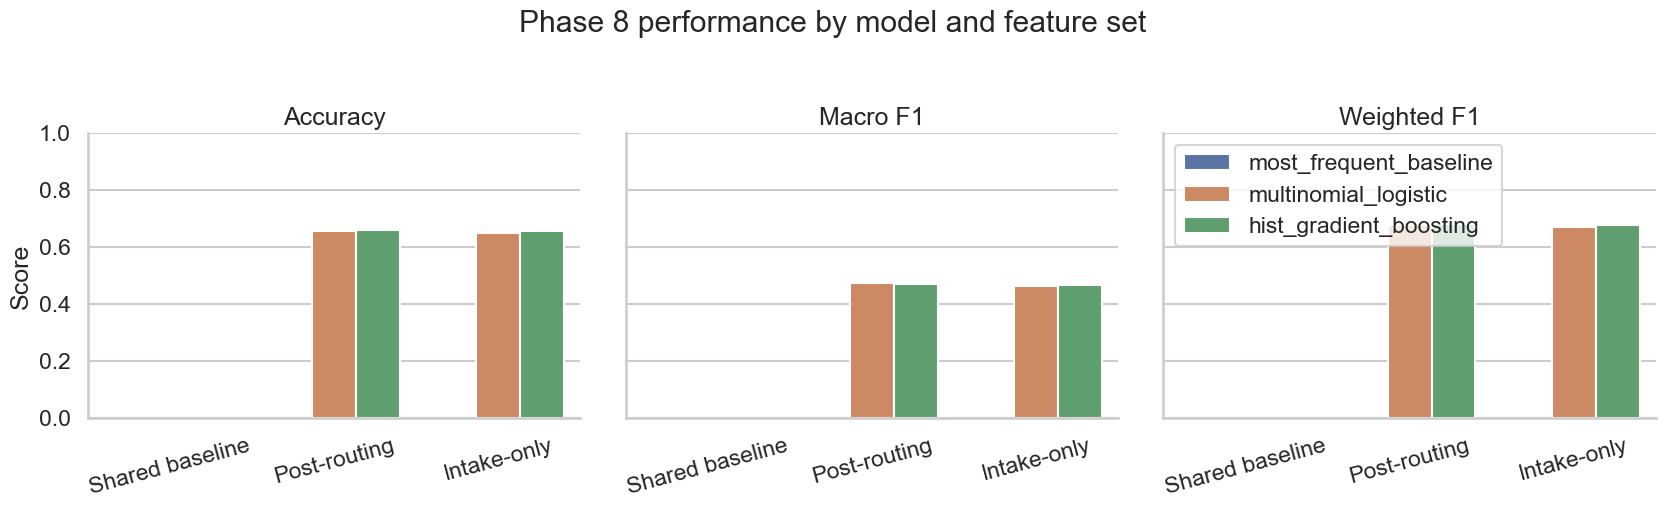

In [4]:
comparison_table = (
    benchmark_overall.pivot_table(
        index=['feature_set', 'model_name'],
        columns='metric',
        values='metric_value',
        aggfunc='first',
    )
    .reset_index()
)
comparison_table['feature_set'] = comparison_table['feature_set'].map(FEATURE_SET_LABELS)
display(trim_table(comparison_table, percent_cols=['accuracy', 'macro_f1', 'weighted_f1']))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, metric in zip(axes, ['accuracy', 'macro_f1', 'weighted_f1']):
    metric_df = benchmark_overall.loc[benchmark_overall['metric'].eq(metric)].copy()
    sns.barplot(data=metric_df, x='feature_set', y='metric_value', hue='model_name', ax=ax, palette='deep')
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.set_ylabel('Score' if metric == 'accuracy' else '')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xticklabels([FEATURE_SET_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=15)
    if metric != 'weighted_f1':
        ax.legend_.remove()
    else:
        ax.legend(title='')
plt.suptitle('Phase 8 performance by model and feature set', y=1.03)
plt.tight_layout()
plt.show()


## Confusion Matrix

These heatmaps use the best non-baseline benchmark inside each feature set. They show whether the model mainly misses by one adjacent duration bucket or makes larger category jumps.


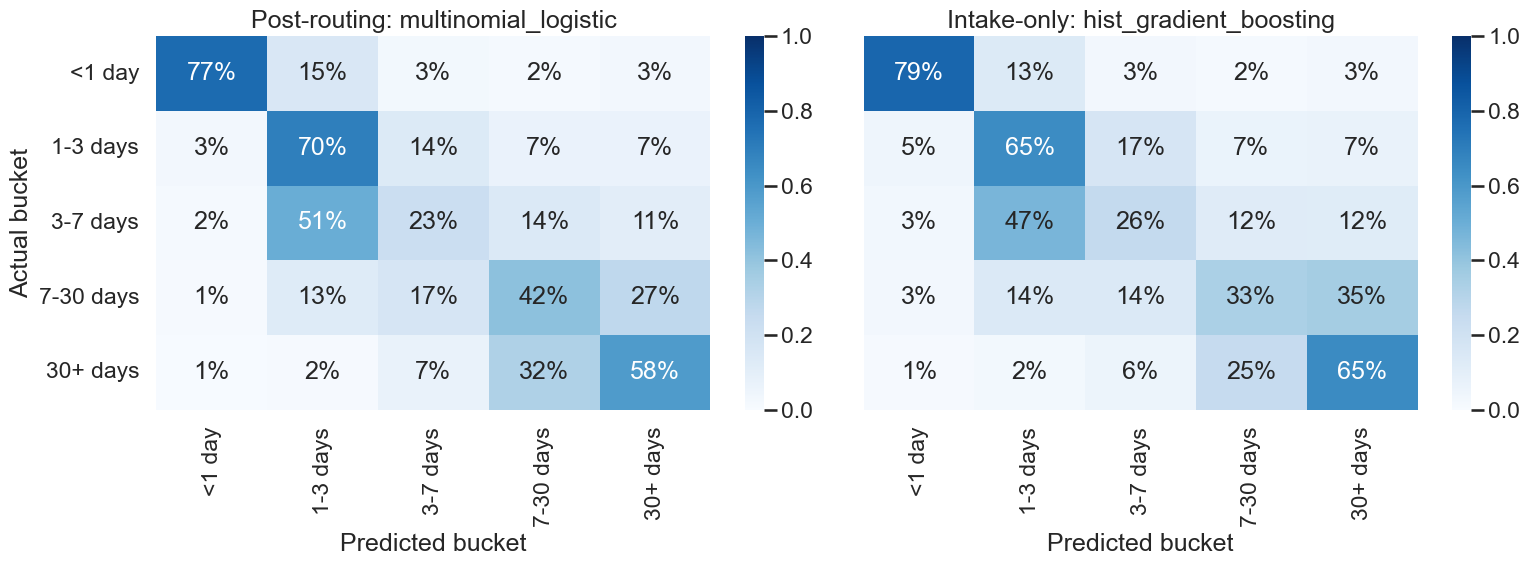

In [5]:
bucket_order = ["<1 day", "1-3 days", "3-7 days", "7-30 days", "30+ days"]

def confusion_heatmap_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.assign(
            actual_resolution_bucket=pd.Categorical(frame['actual_resolution_bucket'], categories=bucket_order, ordered=True),
            predicted_resolution_bucket=pd.Categorical(frame['predicted_resolution_bucket'], categories=bucket_order, ordered=True),
        )
        .pivot(index='actual_resolution_bucket', columns='predicted_resolution_bucket', values='actual_bucket_share')
        .loc[bucket_order, bucket_order]
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.heatmap(confusion_heatmap_frame(post_routing_best_confusion), annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title(f"Post-routing: {post_routing_best_model}")
axes[0].set_xlabel('Predicted bucket')
axes[0].set_ylabel('Actual bucket')

sns.heatmap(confusion_heatmap_frame(intake_only_best_confusion), annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Intake-only: {intake_only_best_model}")
axes[1].set_xlabel('Predicted bucket')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


In [6]:
class_display = (
    best_class_metrics.pivot_table(
        index=['feature_set', 'target_class'],
        columns='metric',
        values='metric_value',
        aggfunc='first',
    )
    .reset_index()
    .rename(columns={'feature_set': 'feature_set_label', 'target_class': 'resolution_bucket'})
)
class_display['feature_set_label'] = class_display['feature_set_label'].map(FEATURE_SET_LABELS)
display(trim_table(class_display, percent_cols=['precision', 'recall', 'f1']))


metric,feature_set_label,resolution_bucket,f1,precision,recall,support
0,Post-routing,<1 day,86.5%,98.2%,77.2%,"118,087.0000"
1,Post-routing,1-3 days,52.6%,42.2%,69.7%,"34,323.0000"
2,Post-routing,3-7 days,26.6%,32.6%,22.5%,"24,137.0000"
3,Post-routing,7-30 days,42.1%,42.5%,41.7%,"17,730.0000"
4,Post-routing,30+ days,30.2%,20.4%,58.3%,"5,723.0000"
5,Intake-only,<1 day,87.1%,96.9%,79.1%,"118,087.0000"
6,Intake-only,1-3 days,51.5%,42.8%,64.6%,"34,323.0000"
7,Intake-only,3-7 days,29.1%,33.5%,25.6%,"24,137.0000"
8,Intake-only,7-30 days,36.7%,40.8%,33.4%,"17,730.0000"
9,Intake-only,30+ days,30.5%,19.9%,65.2%,"5,723.0000"


## Logistic Interpretation Layer

The remaining interpretation sections stay focused on the logistic models because they provide cleaner coefficient-based feature summaries and row-level confidence outputs.

For row-level examples, the notebook uses the `post_routing` logistic variant so the slice diagnostics stay aligned with the stronger operational use case.


,model_name,feature_set,feature,feature_group,mean_abs_coefficient,max_abs_coefficient,strongest_class,feature_set_label
0,multinomial_logistic,post_routing,categorical__agency_NYPD,agency,2.3150,5.0965,<1 day,Post-routing
1,multinomial_logistic,post_routing,categorical__descriptor_Egress - Doors Locked/...,descriptor,1.5116,2.1942,30+ days,Post-routing
2,multinomial_logistic,post_routing,categorical__descriptor_Sidewalk,descriptor,1.4247,2.4481,<1 day,Post-routing
3,multinomial_logistic,post_routing,categorical__descriptor_Noise: air condition/v...,descriptor,1.3505,2.5144,30+ days,Post-routing
4,multinomial_logistic,post_routing,categorical__descriptor_Sewer Backup (Use Comm...,descriptor,1.3275,3.3188,<1 day,Post-routing
5,multinomial_logistic,post_routing,categorical__descriptor_Building Shaking/Vibra...,descriptor,1.3136,2.6454,30+ days,Post-routing
6,multinomial_logistic,post_routing,categorical__descriptor_Fire Hydrant Emergency...,descriptor,1.2853,3.2133,<1 day,Post-routing
7,multinomial_logistic,post_routing,categorical__descriptor_Pothole - Highway,descriptor,1.1650,2.3121,30+ days,Post-routing
8,multinomial_logistic,post_routing,categorical__descriptor_Working Contrary To St...,descriptor,1.0930,2.0520,30+ days,Post-routing
9,multinomial_logistic,post_routing,categorical__complaint_type_Lost Property,complaint,1.0860,1.7726,30+ days,Post-routing


/var/folders/r3/1w14k3xx03lg9cwlb0ndn7s40000gn/T/ipykernel_84427/1730794654.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


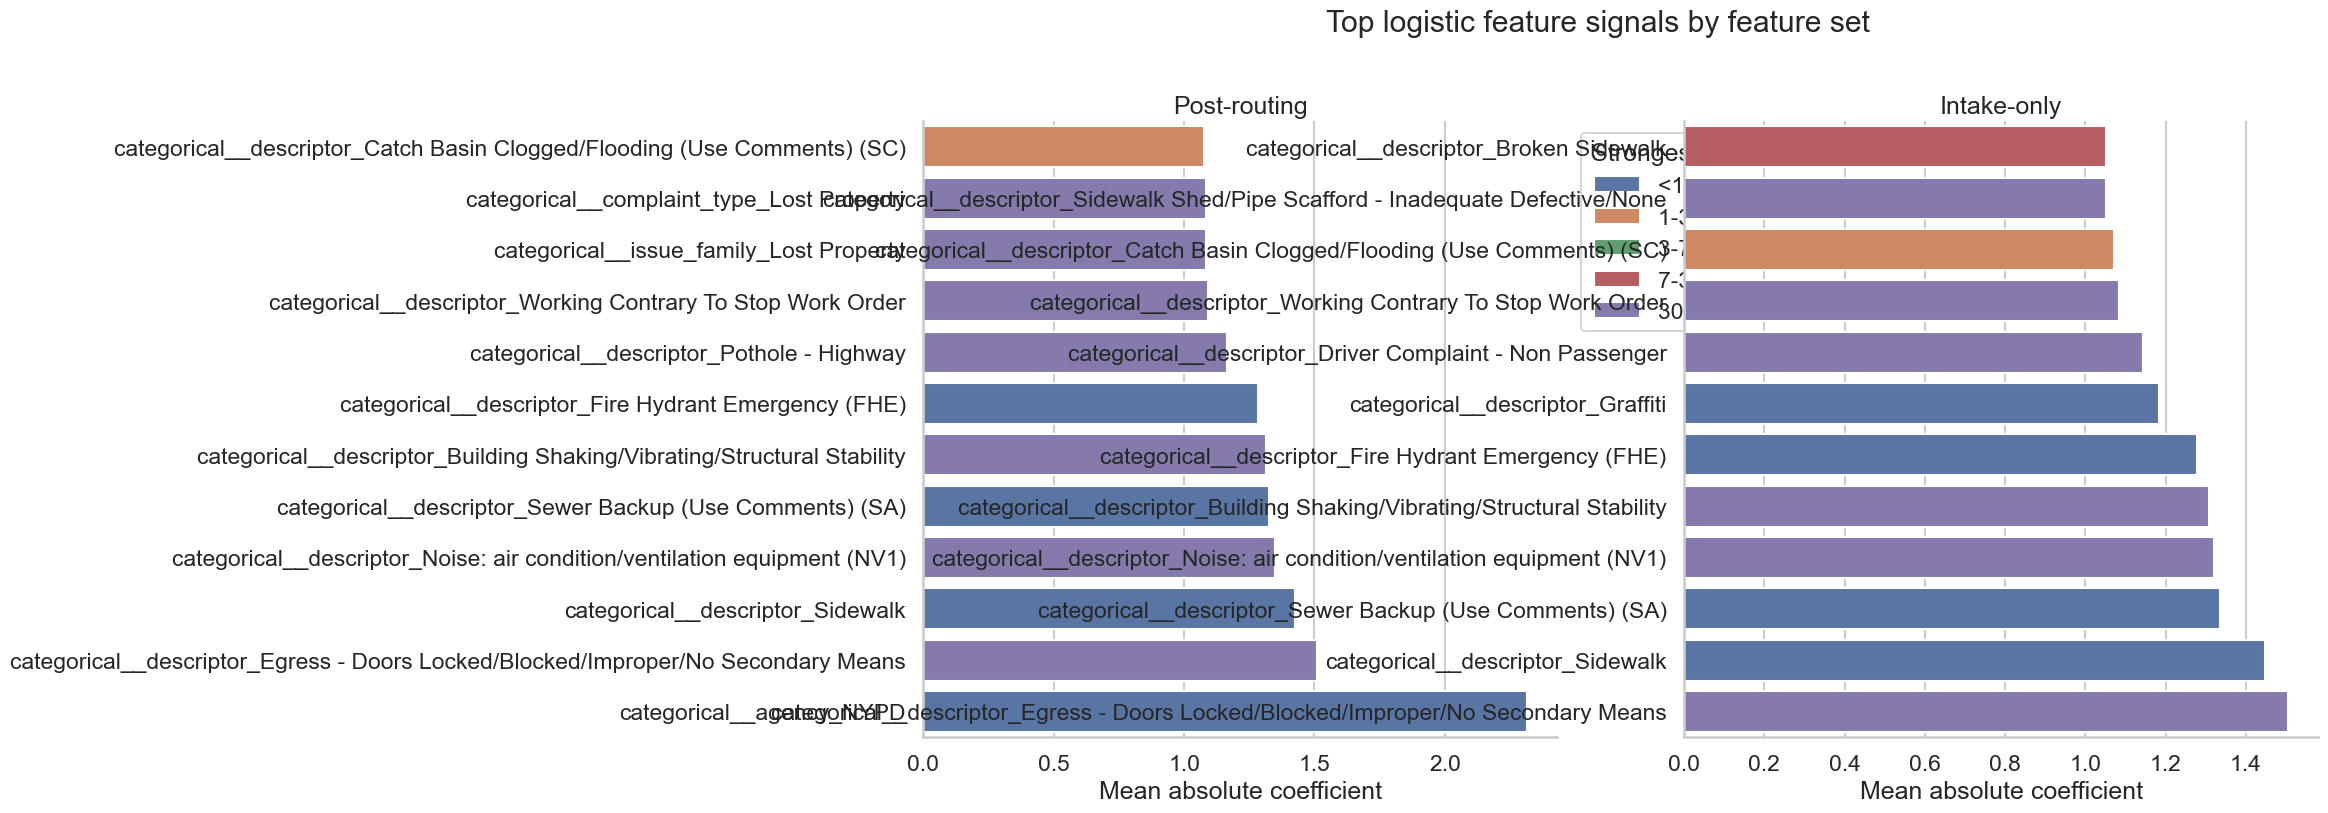

In [7]:
feature_display = feature_importance.loc[feature_importance['model_name'].eq('multinomial_logistic')].copy()
feature_display['feature_set_label'] = feature_display['feature_set'].map(FEATURE_SET_LABELS)
display(feature_display.groupby('feature_set').head(TOP_FEATURES))

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=False)
for ax, feature_set in zip(axes, ['post_routing', 'intake_only']):
    top_features = feature_display.loc[feature_display['feature_set'].eq(feature_set)].head(TOP_FEATURES).sort_values('mean_abs_coefficient')
    sns.barplot(
        data=top_features,
        x='mean_abs_coefficient',
        y='feature',
        hue='strongest_class',
        dodge=False,
        palette='deep',
        ax=ax,
    )
    ax.set_title(FEATURE_SET_LABELS[feature_set])
    ax.set_xlabel('Mean absolute coefficient')
    ax.set_ylabel('')
    if feature_set == 'post_routing':
        ax.legend(title='Strongest class', bbox_to_anchor=(1.02, 1), loc='upper left')
    else:
        ax.legend_.remove()
plt.suptitle('Top logistic feature signals by feature set', y=1.02)
plt.tight_layout()
plt.show()


## Error Slices

These slices come from the logistic models. Comparing them across feature sets helps show where removing `agency` meaningfully weakens the forecast and where the complaint record already carries most of the signal.


,segment_value,complaints,accuracy,median_confidence,top_actual_bucket,top_predicted_bucket,model_name,feature_set,segment_column,slice_label
0,DOB,5946,19.8%,0.6291,<1 day,30+ days,multinomial_logistic,Post-routing,agency,agency | DOB
14,Street Condition,7496,20.0%,0.5356,<1 day,1-3 days,multinomial_logistic,Post-routing,complaint_type,complaint_type | Street Condition
39,Street Condition,7496,20.0%,0.5356,<1 day,1-3 days,multinomial_logistic,Post-routing,issue_family,issue_family | Street Condition
15,General Construction/Plumbing,1783,20.9%,0.5973,<1 day,30+ days,multinomial_logistic,Post-routing,complaint_type,complaint_type | General Construction/Plumbing
40,General Construction/Plumbing,1783,20.9%,0.5973,<1 day,30+ days,multinomial_logistic,Post-routing,issue_family,issue_family | General Construction/Plumbing
1,DPR,2591,21.4%,0.4698,<1 day,30+ days,multinomial_logistic,Post-routing,agency,agency | DPR
16,Derelict Vehicles,1803,32.2%,0.6132,<1 day,1-3 days,multinomial_logistic,Post-routing,complaint_type,complaint_type | Derelict Vehicles
41,Derelict Vehicles,1803,32.2%,0.6132,<1 day,1-3 days,multinomial_logistic,Post-routing,issue_family,issue_family | Derelict Vehicles
17,PLUMBING,3982,34.1%,0.3850,7-30 days,7-30 days,multinomial_logistic,Post-routing,complaint_type,complaint_type | PLUMBING
42,PLUMBING,3982,34.1%,0.3850,7-30 days,7-30 days,multinomial_logistic,Post-routing,issue_family,issue_family | PLUMBING


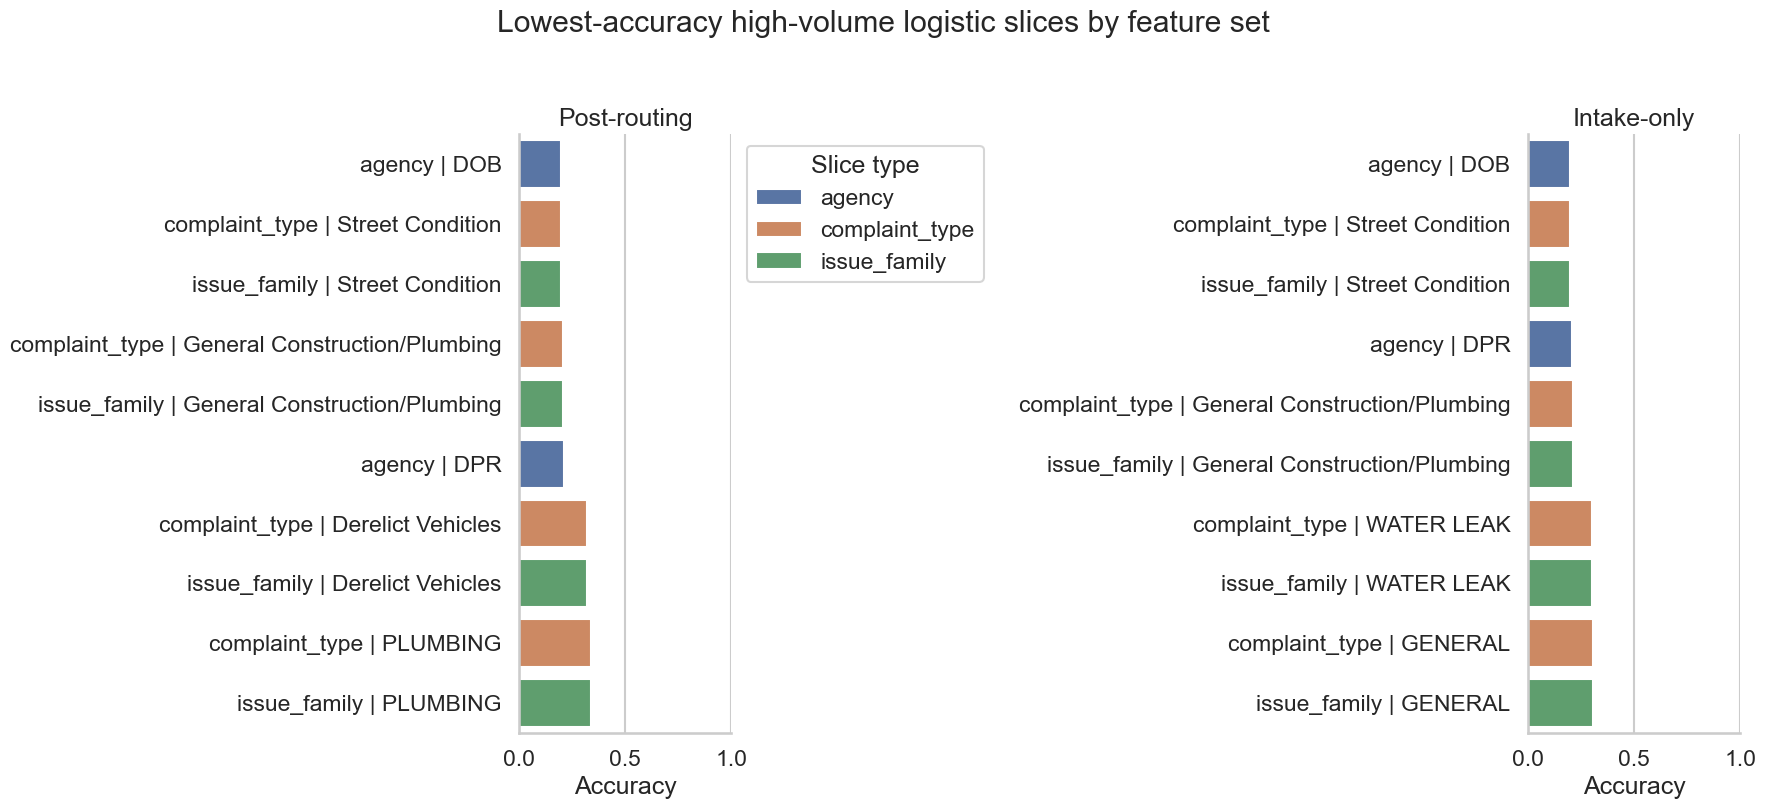

In [8]:
slice_display = (
    error_slices.sort_values(['feature_set', 'accuracy', 'complaints'], ascending=[True, True, False])
    .groupby('feature_set')
    .head(TOP_ERROR_SLICES)
    .copy()
)
slice_display['feature_set'] = slice_display['feature_set'].map(FEATURE_SET_LABELS)
slice_display['slice_label'] = slice_display['segment_column'] + ' | ' + slice_display['segment_value'].astype(str)
display(trim_table(slice_display, percent_cols=['accuracy']))

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True)
for ax, feature_set in zip(axes, ['Post-routing', 'Intake-only']):
    plot_df = slice_display.loc[slice_display['feature_set'].eq(feature_set)].sort_values('accuracy').head(TOP_ERROR_SLICES)
    sns.barplot(data=plot_df, x='accuracy', y='slice_label', hue='segment_column', palette='deep', ax=ax)
    ax.set_xlim(0, 1)
    ax.set_title(feature_set)
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('')
    if feature_set == 'Post-routing':
        ax.legend(title='Slice type', bbox_to_anchor=(1.02, 1), loc='upper left')
    else:
        ax.legend_.remove()
plt.suptitle('Lowest-accuracy high-volume logistic slices by feature set', y=1.02)
plt.tight_layout()
plt.show()


In [9]:
high_confidence_misses = (
    post_routing_logistic_predictions.loc[~post_routing_logistic_predictions['correct_prediction_flag']]
    .sort_values('predicted_probability', ascending=False)
    .loc[:, [
        'unique_key',
        'complaint_type',
        'descriptor',
        'agency',
        'borough',
        'issue_subtype',
        'resolution_bucket',
        'predicted_resolution_bucket',
        'predicted_probability',
    ]]
    .head(20)
)
display(trim_table(high_confidence_misses, percent_cols=['predicted_probability']))


,unique_key,complaint_type,descriptor,agency,borough,issue_subtype,resolution_bucket,predicted_resolution_bucket,predicted_probability
10246,67403663,Food Establishment,Food Temperature,DOHMH,BRONX,not_modeled,7-30 days,30+ days,99.7%
39807,67573411,Food Establishment,Food Spoiled,DOHMH,MANHATTAN,not_modeled,7-30 days,30+ days,99.3%
138357,68228613,Food Establishment,Food Contaminated,DOHMH,BRONX,not_modeled,7-30 days,30+ days,98.9%
107765,68054133,Food Establishment,Food Spoiled,DOHMH,Unknown,not_modeled,7-30 days,30+ days,98.8%
149723,68292570,Noise - Street/Sidewalk,Loud Music/Party,NYPD,QUEENS,music_party,3-7 days,<1 day,98.6%
9464,67407806,Non-Residential Heat,Inadequate or No Heat,DOHMH,BROOKLYN,not_modeled,7-30 days,30+ days,98.6%
178036,68458696,Illegal Parking,Double Parked Blocking Traffic,NYPD,BROOKLYN,double_parked,1-3 days,<1 day,98.4%
77335,67858788,Noise - Residential,Loud Music/Party,NYPD,BRONX,music_party,1-3 days,<1 day,98.3%
192484,68566683,Noise - Street/Sidewalk,Loud Music/Party,NYPD,BROOKLYN,music_party,1-3 days,<1 day,98.2%
178155,68469461,Noise - Residential,Loud Talking,NYPD,BROOKLYN,loud_talking,1-3 days,<1 day,98.1%


## Takeaways

Phase 8 now supports both forecasting views:
- `post_routing` keeps `agency` and is the stronger operational forecast
- `intake_only` removes `agency` and stays surprisingly close, which means the incoming complaint record already carries substantial duration signal

That split makes the modeling work more useful for the project because it now separates routing-dependent prediction from a cleaner pre-routing benchmark.
